In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [4]:
# --- 1.1 加载数据 ---
file_path = './modern_bert_embedding_data_base/MASK_encoder_layer11.csv'
try:
    df = pd.read_csv(file_path)
except FileNotFoundError:
    print(f"错误：找不到文件 '{file_path}'。请检查文件名和路径是否正确。")
    exit()

# 分离标签和数值数据
## 第一列是关系标签
labels = df.iloc[:, 0].values
## 其余列是768维的嵌入向量
embedding_data = df.iloc[:, 1:].values

print(f"数据加载成功！共 {len(labels)} 个关系，每个关系有 {embedding_data.shape[1]} 个维度。")

# --- 1.2 数据标准化 ---
## 创建一个标准化处理器
scaler = StandardScaler()
## 对数据进行标准化 (使其均值为0，方差为1)
scaled_data = scaler.fit_transform(embedding_data)

print("数据标准化完成。")

数据加载成功！共 142 个关系，每个关系有 768 个维度。
数据标准化完成。


d:\Anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 32047 (\N{CJK UNIFIED IDEOGRAPH-7D2F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 31215 (\N{CJK UNIFIED IDEOGRAPH-79EF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 35299 (\N{CJK UNIFIED IDEOGRAPH-89E3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 37322 (\N{CJK UNIFIED IDEOGRAPH-91CA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26041 (\N{CJK UNIFIED IDEOGRAPH-65B9}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda\Lib\site

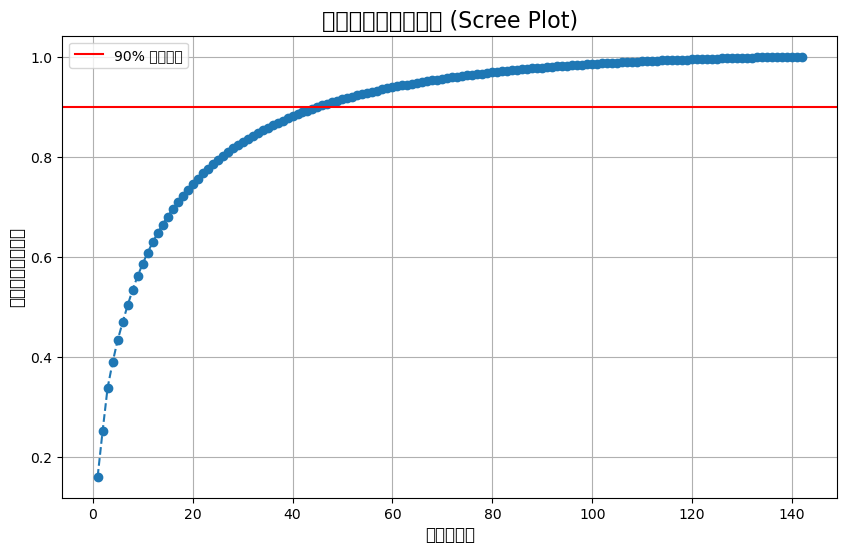

前20个主成分的解释方差贡献率:
  PC-1: 16.01%
  PC-2: 9.17%
  PC-3: 8.64%
  PC-4: 5.06%
  PC-5: 4.41%
  PC-6: 3.57%
  PC-7: 3.42%
  PC-8: 3.09%
  PC-9: 2.75%
  PC-10: 2.44%
  PC-11: 2.23%
  PC-12: 2.08%
  PC-13: 1.85%
  PC-14: 1.72%
  PC-15: 1.60%
  PC-16: 1.52%
  PC-17: 1.36%
  PC-18: 1.31%
  PC-19: 1.20%
  PC-20: 1.12%
第20到40个主成分的解释方差贡献率:
  PC-1: 1.07%
  PC-2: 1.04%
  PC-3: 0.97%
  PC-4: 0.90%
  PC-5: 0.87%
  PC-6: 0.79%
  PC-7: 0.77%
  PC-8: 0.72%
  PC-9: 0.70%
  PC-10: 0.66%
  PC-11: 0.61%
  PC-12: 0.60%
  PC-13: 0.56%
  PC-14: 0.52%
  PC-15: 0.49%
  PC-16: 0.48%
  PC-17: 0.46%
  PC-18: 0.45%
  PC-19: 0.43%
  PC-20: 0.41%


In [ ]:
# --- 2.1 运行一个完整的PCA来评估所有成分 ---
pca_full = PCA()
pca_full.fit(scaled_data)

# --- 2.2 计算并可视化累积解释方差 ---
explained_variance_ratio = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

# 绘制碎石图
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.title('累积解释方差贡献率 (Scree Plot)', fontsize=16)
plt.xlabel('主成分数量', fontsize=12)
plt.ylabel('累积解释方差比例', fontsize=12)
plt.grid(True)
# 加上参考线，比如90%的方差阈值
plt.axhline(y=0.90, color='r', linestyle='-', label='90% 解释方差')
plt.legend(loc='best')
plt.show()

# 打印出前几个成分的解释度
print("前20个主成分的解释方差贡献率:")
for i, ratio in enumerate(explained_variance_ratio[:20]):
    print(f"  PC-{i+1}: {ratio*100:.2f}%")




PCA降维后的数据预览:
  relationship        PC1       PC2       PC3       PC4        PC5       PC6  \
0          夫-妻 -19.716699 -9.409832 -0.439539 -8.053252   4.528717 -0.732208   
1          父-子 -14.524112  2.278006 -7.691731 -8.702297  -9.400349 -1.632957   
2          父-女 -21.042460 -7.298850 -5.916414 -6.810062  -8.644442 -7.959156   
3          母-子 -23.831512  1.795944 -5.657314  0.132386 -10.694452 -2.635164   
4          母-女 -18.410214 -3.399693 -6.437777 -1.233849  -6.586221 -6.859189   

         PC7        PC8       PC9  ...      PC31      PC32      PC33  \
0 -10.873348  11.253872  0.287828  ...  1.784298  2.502103  2.730077   
1  -6.647749   1.117316  4.336167  ...  0.863966  3.290663  0.528459   
2  -8.519232  -4.724011  1.159428  ... -2.312845  1.837686 -2.307079   
3  -3.692266   3.684972 -0.325304  ...  2.574730  3.640429 -0.203421   
4 -10.433923   3.483496  4.107403  ... -0.605361  1.514682 -3.322533   

       PC34      PC35      PC36      PC37      PC38      PC39      PC40 

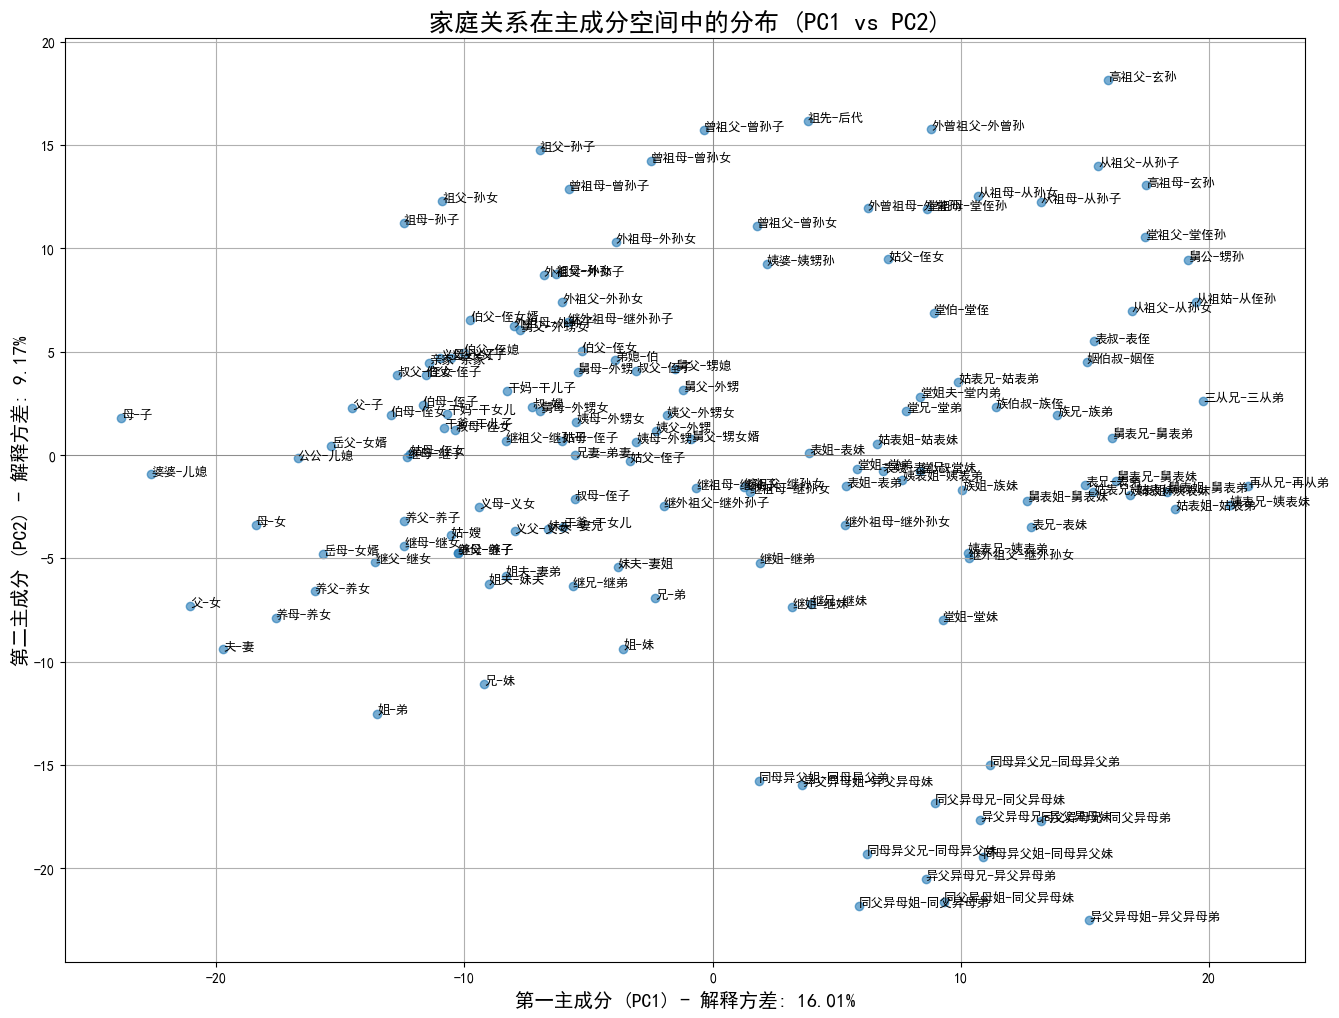

In [11]:
# --- 3.1 确定主成分数量 ---
N_COMPONENTS = 40 

# --- 3.2 执行最终的PCA ---
pca_final = PCA(n_components=N_COMPONENTS)
principal_components = pca_final.fit_transform(scaled_data)

# 将结果存入一个新的DataFrame，方便后续分析
pc_df = pd.DataFrame(data=principal_components, 
                     columns=[f'PC{i+1}' for i in range(N_COMPONENTS)])
pc_df.insert(0, 'relationship', labels)

print("\nPCA降维后的数据预览:")
print(pc_df.head())


# --- 3.3 可视化PC1与PC2 ---
# 为了在图上正确显示中文，我们需要设置字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 'SimHei' 是常用的黑体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

plt.figure(figsize=(16, 12))
pc1_scores = pc_df['PC1']
pc2_scores = pc_df['PC2']

plt.scatter(pc1_scores, pc2_scores, alpha=0.6)

# 在每个点旁边添加关系标签
for i, label in enumerate(pc_df['relationship']):
    plt.text(pc1_scores[i], pc2_scores[i], label, fontsize=9)

plt.title('家庭关系在主成分空间中的分布 (PC1 vs PC2)', fontsize=18)
plt.xlabel(f'第一主成分 (PC1) - 解释方差: {pca_final.explained_variance_ratio_[0]*100:.2f}%', fontsize=14)
plt.ylabel(f'第二主成分 (PC2) - 解释方差: {pca_final.explained_variance_ratio_[1]*100:.2f}%', fontsize=14)
plt.grid(True)
plt.axhline(0, color='grey', linewidth=0.5)
plt.axvline(0, color='grey', linewidth=0.5)
plt.show()

In [12]:
# --- 4.1 解读第一主成分 (PC1) ---
pc1_sorted = pc_df.sort_values(by='PC1', ascending=False)

print("\n--- 解读PC1 ---")
print("PC1得分最高的5个关系 (PC1正半轴):")
print(pc1_sorted[['relationship', 'PC1']].head(5))
print("\nPC1得分最低的5个关系 (PC1负半轴):")
print(pc1_sorted[['relationship', 'PC1']].tail(5))

# --- 4.2 解读第二主成分 (PC2) ---
pc2_sorted = pc_df.sort_values(by='PC2', ascending=False)

print("\n--- 解读PC2 ---")
print("PC2得分最高的5个关系 (PC2正半轴):")
print(pc2_sorted[['relationship', 'PC2']].head(5))
print("\nPC2得分最低的5个关系 (PC2负半轴):")
print(pc2_sorted[['relationship', 'PC2']].tail(5))


--- 解读PC1 ---
PC1得分最高的5个关系 (PC1正半轴):
    relationship        PC1
88       再从兄-再从弟  21.590006
63       姨表兄-姨表妹  20.828883
89       三从兄-三从弟  19.749828
87       从祖姑-从侄孙  19.459749
100        舅公-甥孙  19.166658

PC1得分最低的5个关系 (PC1负半轴):
   relationship        PC1
4           母-女 -18.410214
0           夫-妻 -19.716699
2           父-女 -21.042460
69        婆婆-儿媳 -22.632218
3           母-子 -23.831512

--- 解读PC2 ---
PC2得分最高的5个关系 (PC2正半轴):
   relationship        PC2
21       高祖父-玄孙  18.147091
25        祖先-后代  16.190083
23     外曾祖父-外曾孙  15.787397
17      曾祖父-曾孙子  15.727486
9         祖父-孙子  14.755025

PC2得分最低的5个关系 (PC2负半轴):
    relationship        PC2
135  同母异父姐-同母异父妹 -19.469243
138  异父异母兄-异父异母弟 -20.499691
131  同父异母姐-同父异母妹 -21.622388
133  同父异母姐-同父异母弟 -21.841797
141  异父异母姐-异父异母弟 -22.510924
